## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from datetime import datetime
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='en01-energy-audit'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'energy': '81117ee0a0706bf416bedc50f23b455ee8dd771e588c91b6a420dc3b184f638f'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['energy']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def audit_numeric_table(frame,columns):
    """Audit observed rows; never silently impute or remove them."""
    if frame.empty or frame.index.has_duplicates:
        raise ValueError('Expected a nonempty table with unique row IDs')
    missing=[name for name in columns if name not in frame.columns]
    if missing:raise ValueError('Missing required columns: '+str(missing))
    values=frame[columns].to_numpy(dtype=float)
    if not np.isfinite(values).all():raise ValueError('Non-finite measurements; inspect missing values explicitly')
    return {'rows':len(frame),'features':len(columns),'finite':True,'duplicate_measurement_rows':int(frame[columns].duplicated().sum())}

print("Method ready: audit_numeric_table")


Method ready: audit_numeric_table


In [4]:
def iso_datetimes(values):
    """Parse source ISO dates with the standard library; keep tables as ISO strings."""
    return [datetime.fromisoformat(str(value)) for value in values]

print("Method ready: iso_datetimes")


Method ready: iso_datetimes


### Data and model boundary

The building record contains real ten-minute energy and environmental observations from one source building. Airport weather fields include upstream interpolation and are not colocated calibration references. Beam, circuit and PID examples are declared numerical design models; computed responses do not establish hardware performance or commissioning acceptance.

## Steps

### 1. Check temporal identity and declared units

The source records energy in Wh over ten-minute intervals, not instantaneous power. W=Wh/(10/60 h), so interval-average power is six times the numeric energy field. Timestamps are source-local and no unreported timezone conversion is applied.

In [5]:
energy=snapshot("energy");frame=pd.DataFrame(energy["rows"],columns=energy["columns"])
frame["timestamp"]=frame["date"].astype(str);frame=frame.sort_values("timestamp").reset_index(drop=True)
assert len(frame)==19735 and frame.timestamp.is_unique
dates=iso_datetimes(frame.timestamp)
assert all((b-a).total_seconds()==600 for a,b in zip(dates,dates[1:]))
audit=audit_numeric_table(frame,["Appliances","lights","T1","RH_1"])
assert frame.Appliances.ge(0).all() and frame.lights.ge(0).all()
frame["appliance_average_power_W"]=frame.Appliances/(600/3600)
print("Observed rows:",len(frame),"; energy: Wh/10 min; derived interval-average power: W; source timezone unspecified")
display(frame[["timestamp","Appliances","appliance_average_power_W","T1","RH_1"]].head(8))


Observed rows: 19735 ; energy: Wh/10 min; derived interval-average power: W; source timezone unspecified


,timestamp,Appliances,appliance_average_power_W,T1,RH_1
0,2016-01-11 17:00:00,60,360.0,19.890000,47.596667
1,2016-01-11 17:10:00,60,360.0,19.890000,46.693333
2,2016-01-11 17:20:00,50,300.0,19.890000,46.300000
3,2016-01-11 17:30:00,50,300.0,19.890000,46.066667
4,2016-01-11 17:40:00,60,360.0,19.890000,46.333333
5,2016-01-11 17:50:00,50,300.0,19.890000,46.026667
6,2016-01-11 18:00:00,60,360.0,19.890000,45.766667
7,2016-01-11 18:10:00,60,360.0,19.856667,45.560000


### 2. Inspect measured time patterns

Show the first seven days of derived interval-average appliance power. This is a unit conversion of the measured energy, not a new high-rate electrical measurement. The trace cannot resolve mains voltage/current waveforms.

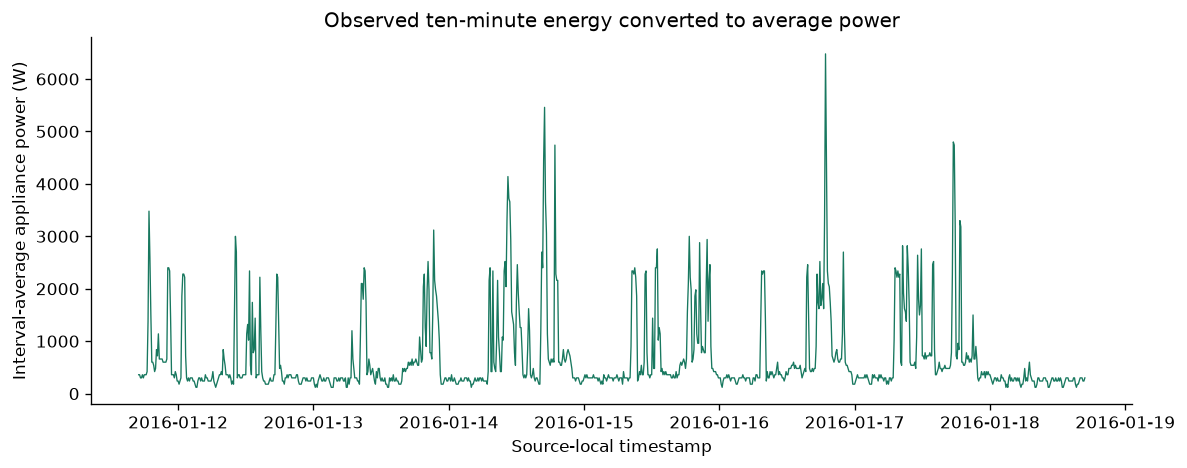

In [6]:
part=frame.iloc[:7*144]
fig,ax=plt.subplots(figsize=(10,4));ax.plot(iso_datetimes(part.timestamp),part.appliance_average_power_W,lw=.8)
ax.set(xlabel="Source-local timestamp",ylabel="Interval-average appliance power (W)",title="Observed ten-minute energy converted to average power");plt.tight_layout();plt.show()


### 3. Compare diurnal distributions

Boxplots group observed interval energy by clock hour across the source period. They do not represent independent household replicates, and differences can mix behavior, weather and season. Keep the Wh/interval label distinct from the previous W plot.

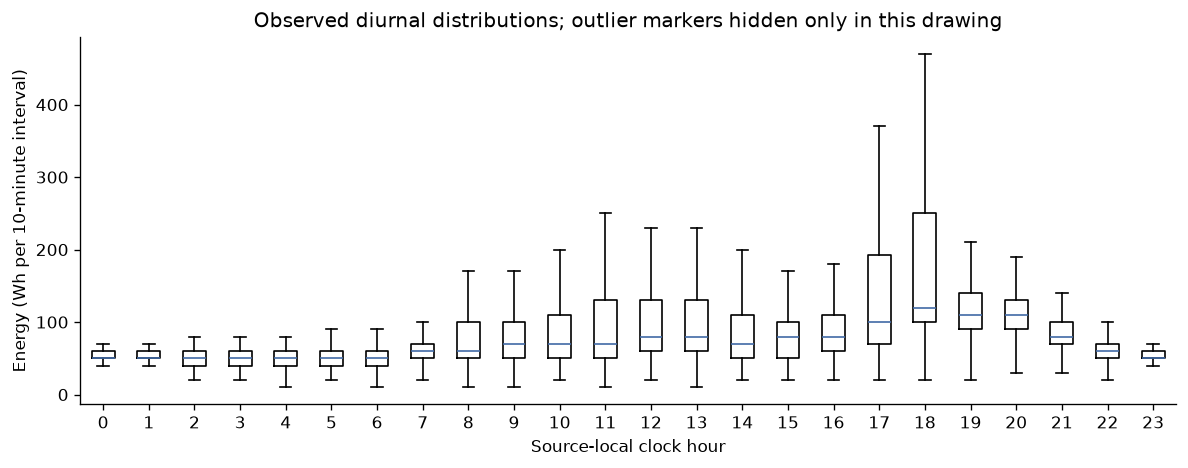

In [7]:
hour=np.array([value.hour for value in dates])
fig,ax=plt.subplots(figsize=(10,4));ax.boxplot([frame.loc[hour==h,"Appliances"] for h in range(24)],tick_labels=range(24),showfliers=False)
ax.set(xlabel="Source-local clock hour",ylabel="Energy (Wh per 10-minute interval)",title="Observed diurnal distributions; outlier markers hidden only in this drawing");plt.tight_layout();plt.show()


### 4. Read colocated environmental observations

The kitchen temperature/humidity scatter is a measured association in one building. It does not calibrate the energy meter or identify a causal controller rule. Plot source humidity as percent, and temperature in degrees Celsius.

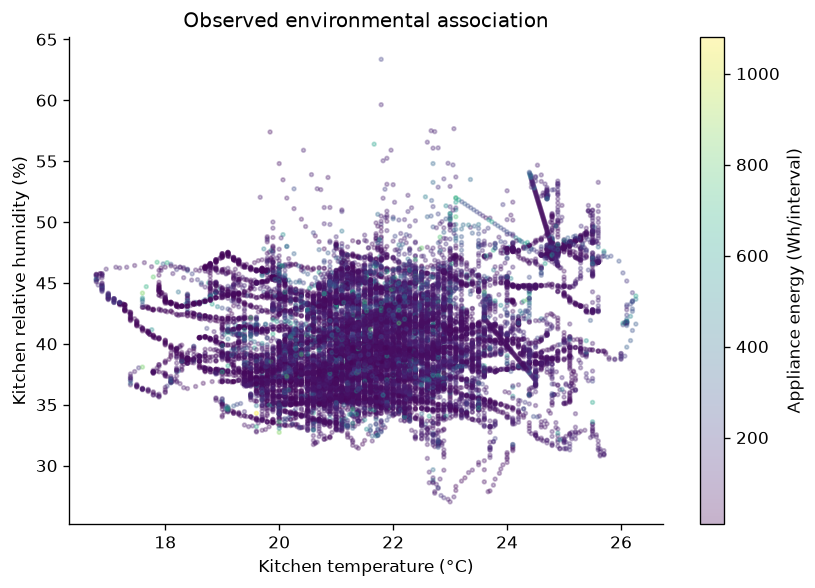

In [8]:
fig,ax=plt.subplots(figsize=(7,5));im=ax.scatter(frame.T1,frame.RH_1,c=frame.Appliances,s=5,alpha=.3,cmap="viridis")
ax.set(xlabel="Kitchen temperature (°C)",ylabel="Kitchen relative humidity (%)",title="Observed environmental association")
fig.colorbar(im,ax=ax,label="Appliance energy (Wh/interval)");plt.tight_layout();plt.show()


### 5. Reconcile energy totals and export the audit

Summing Wh observations gives energy over the observed intervals. Integrating interval-average W with the exact interval duration recovers the same total. Preserve timestamp cadence and original values in the export.

In [9]:
total_Wh=float(frame.Appliances.sum());integrated_Wh=float((frame.appliance_average_power_W*(600/3600)).sum())
assert np.isclose(total_Wh,integrated_Wh)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
frame[["timestamp","Appliances","appliance_average_power_W","T1","RH_1"]].to_csv(OUTPUT_DIR/"observed-energy-audit.csv",index=False)
(OUTPUT_DIR/"units-and-cadence.json").write_text(json.dumps({"rows":len(frame),"interval_seconds":600,"original_energy_unit":"Wh per interval","derived_power_unit":"W interval average","total_observed_Wh":total_Wh,"timezone":"source unspecified; no conversion"},indent=2))
print("Energy reconciliation passed; exports:",OUTPUT_DIR)


Energy reconciliation passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/en01-energy-audit


## Exercises and reference explanation

1. Convert 100 Wh per ten minutes to interval-average W.
2. Why are repeated time observations not independent buildings?

**Reference explanation.** The average is 600 W. The record follows one building through time, so household generalization and observation independence require additional design evidence.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/Pandas/Matplotlib, add a daily observed-energy total with complete-interval counts.

**Prompt 2**

> With the same packages, compare kitchen and living-room temperatures without calling either an instrument calibration reference.

**Human acceptance.** Cadence remains ten minutes, original Wh data is preserved and every derived power/energy unit is explicit.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [10]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [UCI energy](https://archive.ics.uci.edu/static/public/374/appliances+energy+prediction.zip) — CC BY 4.0; credit UCI and original dataset authors; retrieved 2026-10-09. SHA-256 `2fccf354445d886e7917620b0195db1f3e3e34d5a067a93b844694a4c561255a`.
  Extract energydata_complete.csv from original download; preserve all rows and declared units; no imputation.
  Candanedo, L. (2017). Appliances Energy Prediction. UCI Machine Learning Repository. DOI: 10.24432/C5VC8G.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.